In [40]:
# Imports
import random
import networkx as nx
import numpy as np
import scipy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sci
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from networkx.algorithms.community import louvain_communities
import xgboost as xgb


In [41]:
data_path = "../dataset/com-dblp.ungraph.txt"

G = nx.read_edgelist(data_path, comments='#', nodetype=int, create_using=nx.Graph())

print("Graph Info")
print("Nodes: ", G.number_of_nodes())
print("Edges: ", G.number_of_edges())

Graph Info
Nodes:  317080
Edges:  1049866


In [42]:
import networkx as nx

# 1. Pick a well-connected seed hub
degrees = dict(G.degree())
seed_node = max(degrees, key=degrees.get)

# 2. Perform BFS Snowball Sampling up to ~5,000 nodes
target_nodes = 5000
sampled_nodes = {seed_node}
queue = [seed_node]

while queue and len(sampled_nodes) < target_nodes:
    curr = queue.pop(0)
    for neighbor in G.neighbors(curr):
        if neighbor not in sampled_nodes:
            sampled_nodes.add(neighbor)
            queue.append(neighbor)
            if len(sampled_nodes) >= target_nodes:
                break

# 3. Extract induced subgraph and its Largest Connected Component
subgraph = G.subgraph(sampled_nodes).copy()
lcc_nodes = max(nx.connected_components(subgraph), key=len)
dense_component_graph = subgraph.subgraph(lcc_nodes).copy()

print("Snowball Sampled Graph:")
print(f"Nodes: {dense_component_graph.number_of_nodes():,}")
print(f"Edges: {dense_component_graph.number_of_edges():,}")

Snowball Sampled Graph:
Nodes: 5,000
Edges: 32,569


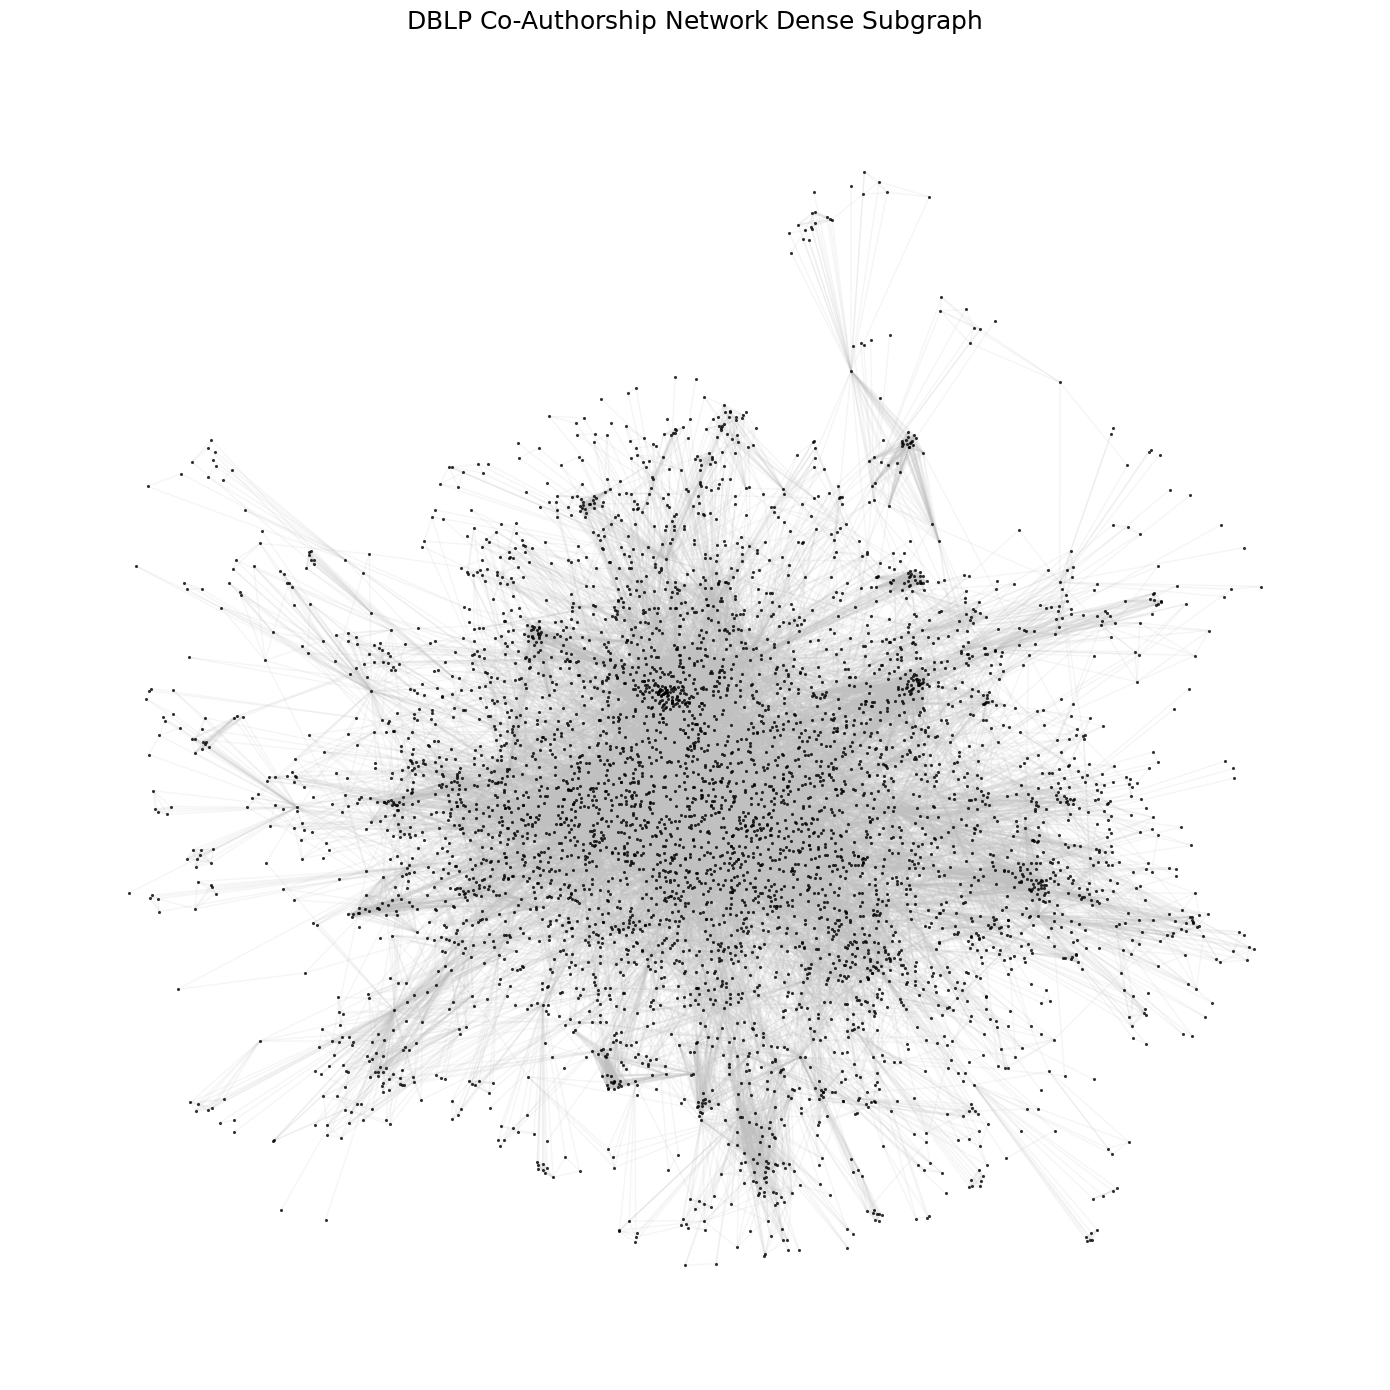

In [43]:
plt.figure(figsize=(14, 14))
plt.title("DBLP Co-Authorship Network Dense Subgraph", fontsize=18, pad=20)

pos = nx.spring_layout(dense_component_graph, seed=42, k=0.15)

nx.draw_networkx_edges(
    dense_component_graph, 
    pos, 
    alpha=0.15, 
    edge_color="silver",
    width=1
)

nx.draw_networkx_nodes(
    dense_component_graph, 
    pos, 
    node_size=5, 
    node_color="black", 
    alpha=0.8,
    linewidths=0
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [44]:
communities = louvain_communities(dense_component_graph, seed=42)


print("louvain Communities:", len(communities))


community_sizes = [len(c) for c in communities]
community_sizes_sorted = sorted(community_sizes, reverse=True)

print(f"Largest Community Size  : {community_sizes_sorted[0]} authors")
print(f"Smallest Community Size : {community_sizes_sorted[-1]} authors")
print(f"Average Community Size  : {np.mean(community_sizes):.2f} authors")
print(f"Median Community Size   : {np.median(community_sizes):.2f} authors")

node_to_community = {}
for comm_id, comm_nodes in enumerate(communities):
    for node in comm_nodes:
        node_to_community[node] = comm_id

nx.set_node_attributes(dense_component_graph, node_to_community, name="community")

louvain Communities: 32
Largest Community Size  : 446 authors
Smallest Community Size : 3 authors
Average Community Size  : 156.25 authors
Median Community Size   : 139.50 authors


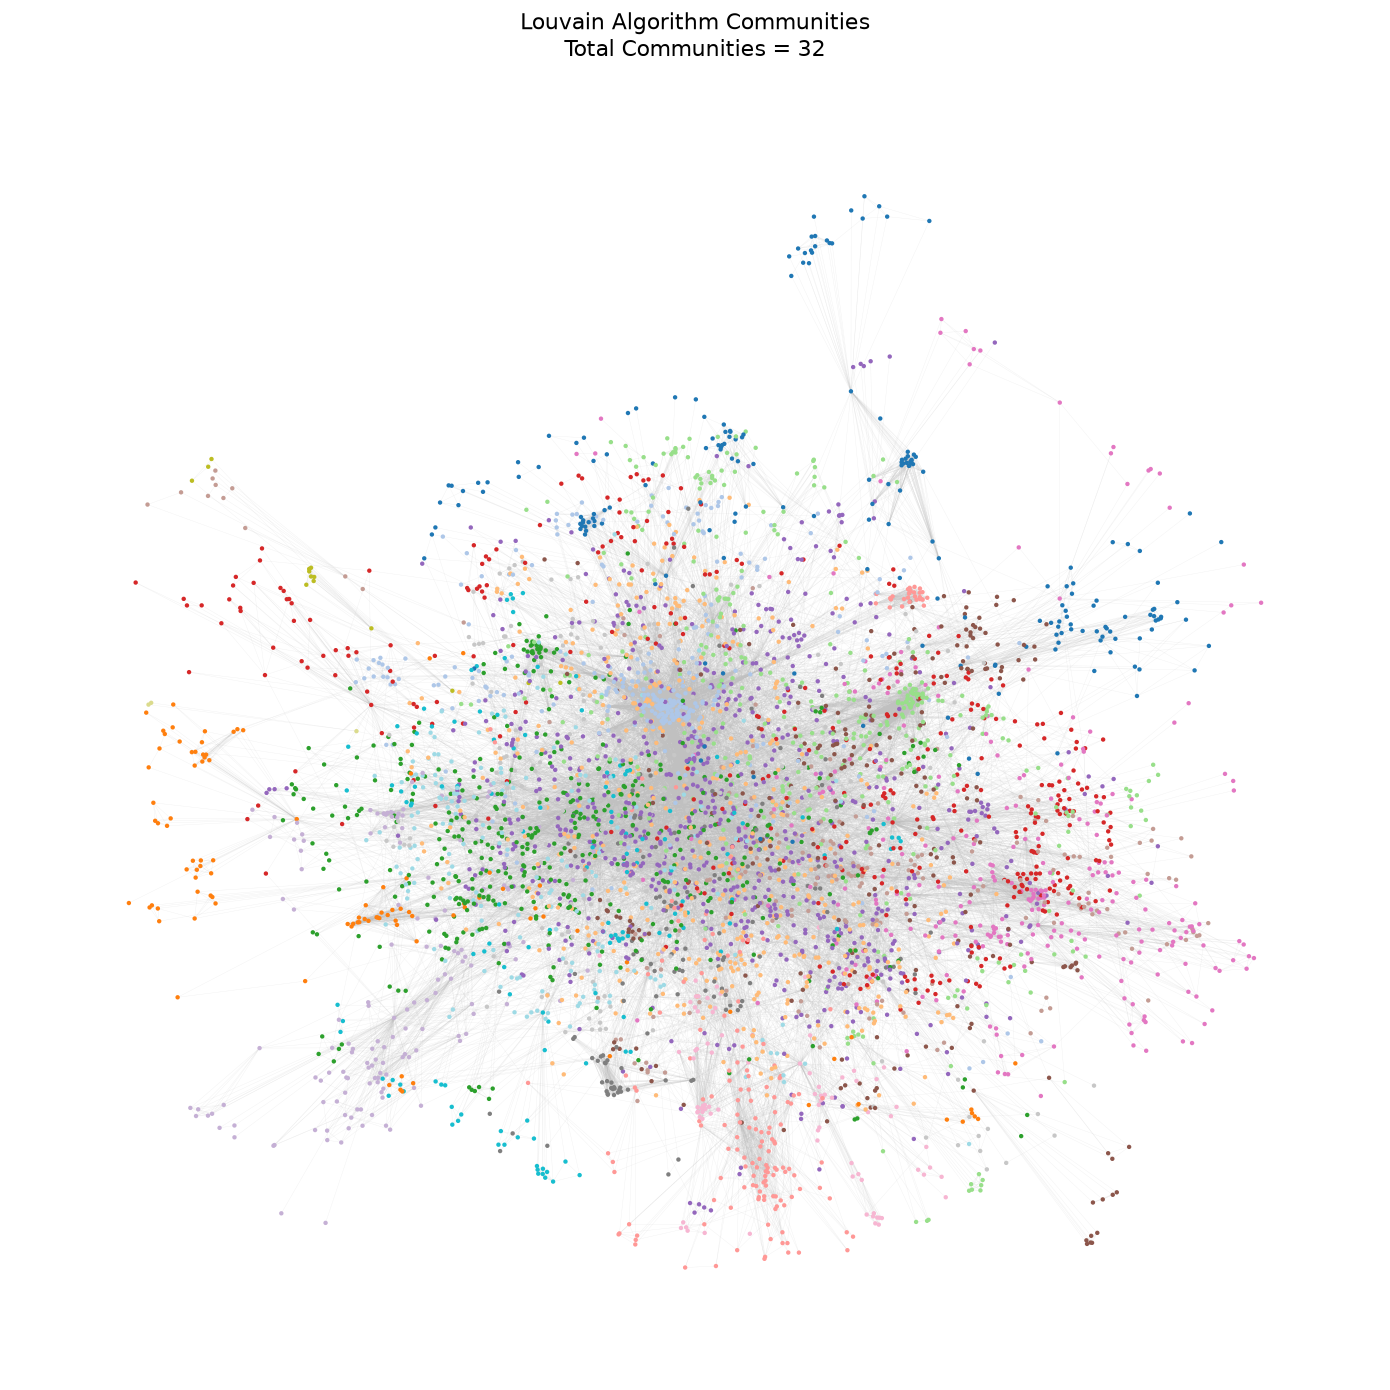

In [45]:
num_communities = len(communities)
cmap = plt.get_cmap('tab20', min(num_communities, 20))

node_colors = [node_to_community[node] % 20 for node in dense_component_graph.nodes()]

plt.figure(figsize=(14, 14))
plt.title(
    f"Louvain Algorithm Communities\n"
    f"Total Communities = {num_communities}", 
    fontsize=16, 
    pad=20
)


pos = nx.spring_layout(dense_component_graph, seed=42, k=0.15)

nx.draw_networkx_edges(
    dense_component_graph, 
    pos, 
    alpha=0.25, 
    edge_color="silver", 
    width=0.25
)

nodes_plot = nx.draw_networkx_nodes(
    dense_component_graph, 
    pos, 
    node_size=10, 
    node_color=node_colors, 
    cmap=cmap,
    alpha=1,
    linewidths=0
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [46]:
# Install cdlib if not present in your environment
# !pip install cdlib

from cdlib import algorithms
import numpy as np
import networkx as nx

# 1. Run BigCLAM Overlapping Community Detection
bigclam_comms = algorithms.big_clam(dense_component_graph)
communities = bigclam_comms.communities

print("BigCLAM Communities:", len(communities))

# 2. Print Community Statistics
community_sizes = [len(c) for c in communities]
community_sizes_sorted = sorted(community_sizes, reverse=True)

print(f"Largest Community Size  : {community_sizes_sorted[0]} authors")
print(f"Smallest Community Size : {community_sizes_sorted[-1]} authors")
print(f"Average Community Size  : {np.mean(community_sizes):.2f} authors")
print(f"Median Community Size   : {np.median(community_sizes):.2f} authors")

# 3. Map Primary Community ID for Visualization
node_to_community = {}
for comm_id, comm_nodes in enumerate(communities):
    for node in comm_nodes:
        # Assign the first community encountered as primary
        if node not in node_to_community:
            node_to_community[node] = comm_id

# Handle any isolated unassigned nodes
for node in dense_component_graph.nodes():
    if node not in node_to_community:
        node_to_community[node] = 0

# Set attribute so your visualization script works directly
nx.set_node_attributes(dense_component_graph, node_to_community, name="community")

BigCLAM Communities: 8
Largest Community Size  : 4065 authors
Smallest Community Size : 78 authors
Average Community Size  : 625.00 authors
Median Community Size   : 138.50 authors


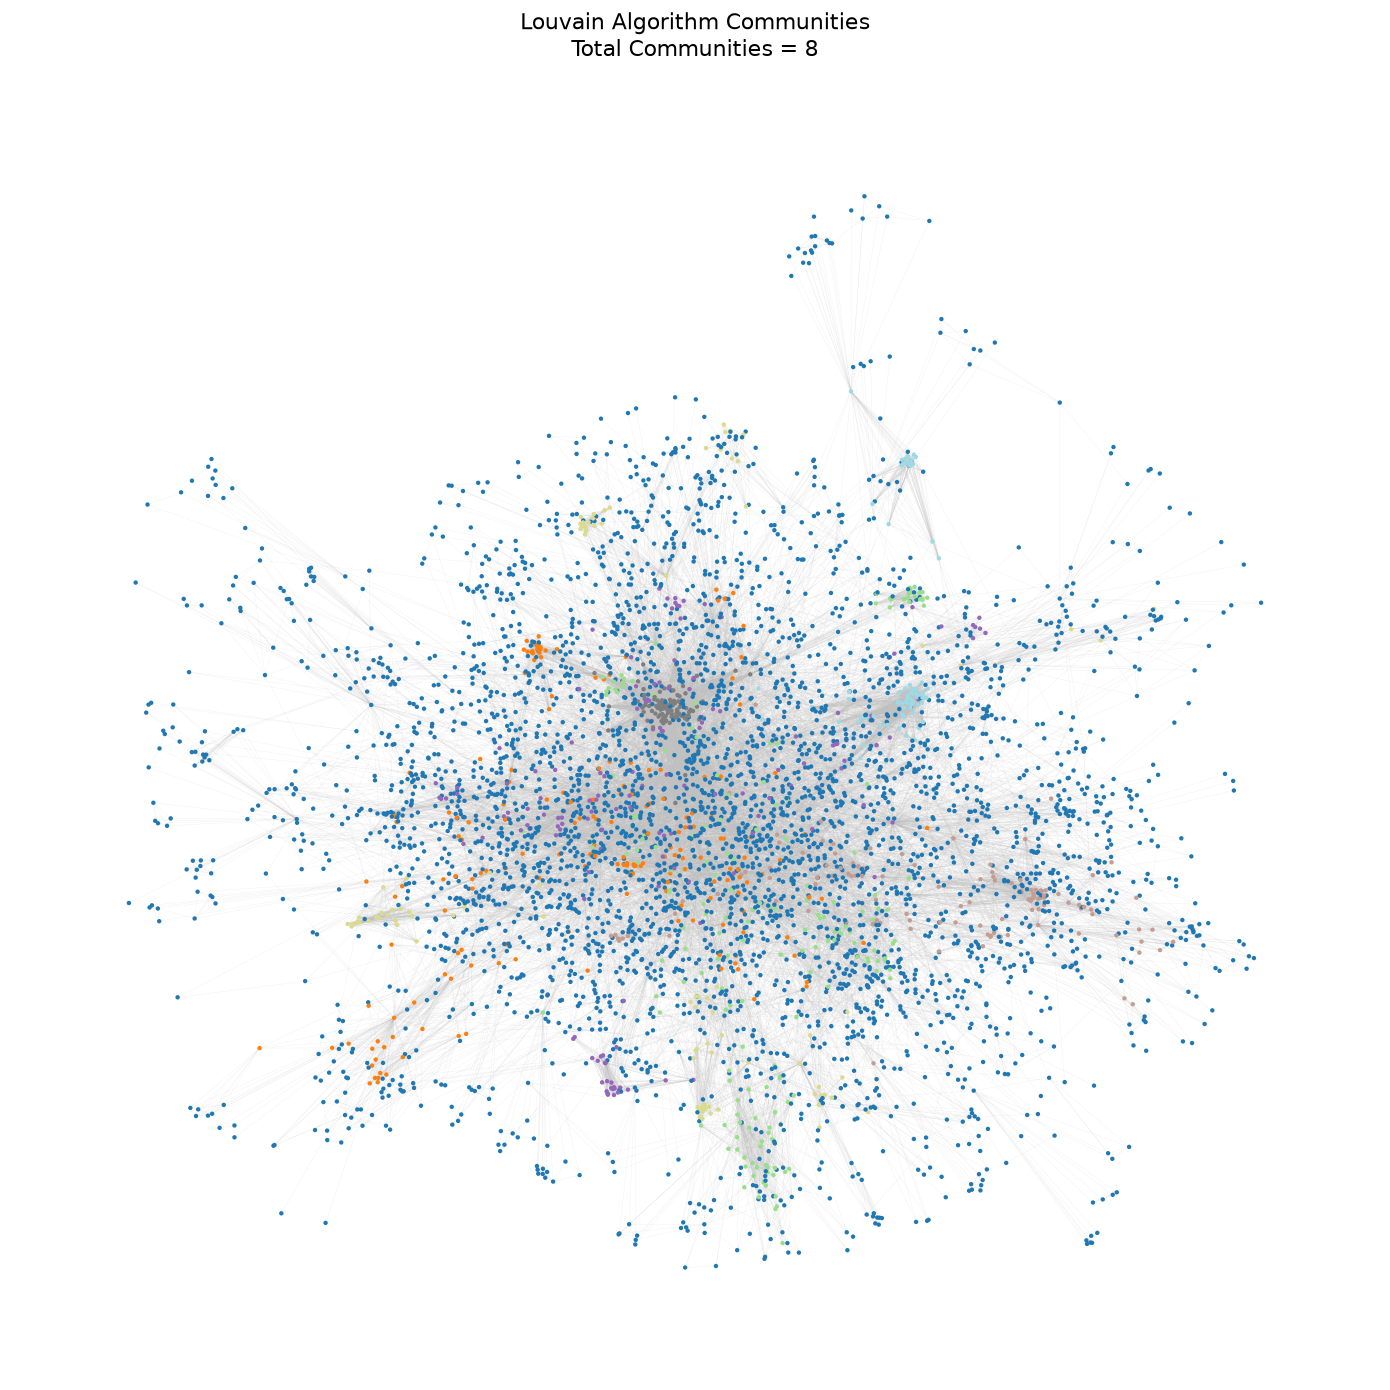

In [47]:
num_communities = len(communities)
cmap = plt.get_cmap('tab20', min(num_communities, 20))

node_colors = [node_to_community[node] % 20 for node in dense_component_graph.nodes()]

plt.figure(figsize=(14, 14))
plt.title(
    f"Louvain Algorithm Communities\n"
    f"Total Communities = {num_communities}", 
    fontsize=16, 
    pad=20
)


pos = nx.spring_layout(dense_component_graph, seed=42, k=0.15)

nx.draw_networkx_edges(
    dense_component_graph, 
    pos, 
    alpha=0.25, 
    edge_color="silver", 
    width=0.25
)

nodes_plot = nx.draw_networkx_nodes(
    dense_component_graph, 
    pos, 
    node_size=10, 
    node_color=node_colors, 
    cmap=cmap,
    alpha=1,
    linewidths=0
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [48]:
import random
import networkx as nx
import pandas as pd

random.seed(42)

G_original = dense_component_graph.copy()
G_train = G_original.copy()

num_test_edges = int(0.2 * G_original.number_of_edges())

positive_test_edges = []
edges = list(G_original.edges())
random.shuffle(edges)

# 1. Extract Positive Edges (leaves dist(u, v) >= 3 upon removal)
for u, v in edges:
    if len(positive_test_edges) >= num_test_edges:
        break
    if G_train.degree(u) > 1 and G_train.degree(v) > 1:
        G_train.remove_edge(u, v)
        
        # Check nodes reachable within 2 hops
        nbrs_2hop = nx.single_source_shortest_path_length(G_train, u, cutoff=2)
        if v in nbrs_2hop:
            # Distance <= 2, restore edge
            G_train.add_edge(u, v)
        else:
            # Distance >= 3 or disconnected
            if nx.has_path(G_train, u, v):
                positive_test_edges.append((u, v))
            else:
                G_train.add_edge(u, v)

# 2. Hard Negative Sampling (dist >= 3)
negative_test_edges = set()
nodes = list(G_train.nodes())
max_attempts = len(positive_test_edges) * 100
attempts = 0

while len(negative_test_edges) < len(positive_test_edges) and attempts < max_attempts:
    attempts += 1
    u, v = random.sample(nodes, 2)
    edge_pair = (min(u, v), max(u, v))
    
    if not G_train.has_edge(u, v) and edge_pair not in negative_test_edges:
        nbrs_2hop = nx.single_source_shortest_path_length(G_train, u, cutoff=2)
        if v not in nbrs_2hop:
            if nx.has_path(G_train, u, v):
                negative_test_edges.add(edge_pair)

negative_test_edges = list(negative_test_edges)

# 3. Build Test DataFrame
df_pos = pd.DataFrame(positive_test_edges, columns=["node_1", "node_2"])
df_pos["label"] = 1

df_neg = pd.DataFrame(negative_test_edges, columns=["node_1", "node_2"])
df_neg["label"] = 0

test_df = pd.concat([df_pos, df_neg], ignore_index=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Original graph edges : {G_original.number_of_edges():,}")
print(f"Training graph edges : {G_train.number_of_edges():,}")
print(f"Positive test edges  : {len(df_pos):,}")
print(f"Negative test edges  : {len(df_neg):,}")
print(f"Total test samples   : {len(test_df):,}")

Original graph edges : 32,569
Training graph edges : 31,855
Positive test edges  : 714
Negative test edges  : 714
Total test samples   : 1,428


In [ ]:
import scipy.sparse as sp
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import networkx as nx

# 1. Extract candidate pairs from test_df
test_pairs = [(int(row["node_1"]), int(row["node_2"])) for _, row in test_df.iterrows()]

# 2. Compute Local Heuristics (Common Neighbors, Jaccard, Adamic-Adar)
print("Computing local heuristics...")
cn_scores = [len(list(nx.common_neighbors(G_train, u, v))) for u, v in test_pairs]

jaccard_preds = nx.jaccard_coefficient(G_train, test_pairs)
jaccard_scores = [score for u, v, score in jaccard_preds]

aa_preds = nx.adamic_adar_index(G_train, test_pairs)
aa_scores = [score for u, v, score in aa_preds]

# 3. Compute Higher-Order Sparse Katz Index (Paths of length 3 & 4)
print("Computing Sparse Katz Index...")
nodes = list(G_train.nodes())
node_to_idx = {node: idx for idx, node in enumerate(nodes)}

A = nx.to_scipy_sparse_array(G_train, nodelist=nodes, format='csr', dtype=float)

beta = 0.005
A2 = A @ A
A3 = A2 @ A
A4 = A3 @ A
Katz_matrix = (beta**3 * A3) + (beta**4 * A4)

katz_scores = [Katz_matrix[node_to_idx[u], node_to_idx[v]] for u, v in test_pairs]

# 4. Attach all scores to test_df
test_df["cn_score"] = cn_scores
test_df["jaccard_score"] = jaccard_scores
test_df["adamic_adar_score"] = aa_scores
test_df["katz_score"] = katz_scores

# 5. Output Baseline Performance Summary
y_true = test_df["label"]

summary_df = pd.DataFrame({
    "Algorithm / Metric": [
        "Common Neighbors (Local)",
        "Jaccard Coefficient (Local)",
        "Adamic-Adar Index (Local)",
        "Sparse Katz Index (Higher-Order)"
    ],
    "AUC-ROC Score": [
        roc_auc_score(y_true, test_df["cn_score"]),
        roc_auc_score(y_true, test_df["jaccard_score"]),
        roc_auc_score(y_true, test_df["adamic_adar_score"]),
        roc_auc_score(y_true, test_df["katz_score"])
    ]
})

display(summary_df.round(4))